# Grid Pathfinding Visualization Demo

This notebook demonstrates the grid pathfinding experiment framework with visualization capabilities.

## Overview

The framework supports two modes:
- **Visual Mode**: Small grids (~50×50) with frontier tracking for animations
- **Benchmark Mode**: Large grids (up to 1000×1000) for performance analysis

## Features

- Interactive expansion animations
- Path visualization and comparison
- Performance metrics analysis
- Convergence curve plotting
- Configurable algorithm parameters

## 1. Setup and Imports

In [ ]:
# Import required libraries
import sys
import os
import IPython
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import seaborn as sns
import pandas as pd
from pathlib import Path

# Add src to path
src_path = Path.cwd().parent
sys.path.insert(0, str(src_path))
print("Added to path:", src_path)

# Import custom modules
from experiments.grid_experiment import GridExperiment
from problems.discrete import SPProblem
from utils.visualizes.grid_visualization import (
    load_trace, create_grid_animation, plot_path_comparison,
    plot_performance_comparison, plot_convergence_comparison, display_grid
)
from utils.configHelper import load_config

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("✓ All libraries imported successfully")
print(f"✓ Working directory: {os.getcwd()}")
print(f"✓ Source path: {src_path}")

Added to path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src
✓ All libraries imported successfully
✓ Working directory: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\notebooks
✓ Source path: D:\Uni\IT\IntroToAI\AI1_search-algorithms\src


## 2. Load Configuration and Test Data

In [6]:
# Load configuration
config = load_config('../utils/config.json')
print("Configuration loaded:")
print(f"- Grid problem: {config['problems']['grid']}")

# Load test problem from file
test_file = src_path / 'tests' / 'SP' / 'test_1.txt'
if test_file.exists():
    problem = SPProblem(str(test_file))
    print(f"\n✓ Test problem loaded from {test_file}")
    print(f"  Grid size: {problem.n} × {problem.m}")
    print(f"  Start: {problem.start_node}")
    print(f"  End: {problem.end_node}")
    print(f"  Obstacles: {np.sum(problem.grid == 1)}")
    print(f"  Open cells: {np.sum(problem.grid == 0)}")
else:
    print(f"✗ Test file not found: {test_file}")
    print("Creating a small random grid for demonstration...")
    problem = SPProblem.from_array(
        np.array([[0, 0, 0, 1, 0],
                  [1, 0, 0, 1, 0],
                  [0, 0, 1, 0, 0],
                  [0, 1, 0, 0, 0],
                  [0, 0, 0, 0, 0]], dtype=int),
        (0, 0), (4, 4)
    )

Configuration loaded:
- Grid problem: {'name': 'Grid Shortest Path (SP)', 'type': 'discrete', 'test_dir': 'tests/SP', 'test_pattern': 'test_*.txt', 'description': 'Find shortest path in grid maze from S to E', 'metrics': ['best_fitness', 'nodes_expanded', 'execution_time']}

✓ Test problem loaded from D:\Uni\IT\IntroToAI\AI1_search-algorithms\src\tests\SP\test_1.txt
  Grid size: 19 × 19
  Start: (0, 1)
  End: (18, 17)
  Obstacles: 12
  Open cells: 349


## 3. Initialize Grid Experiment

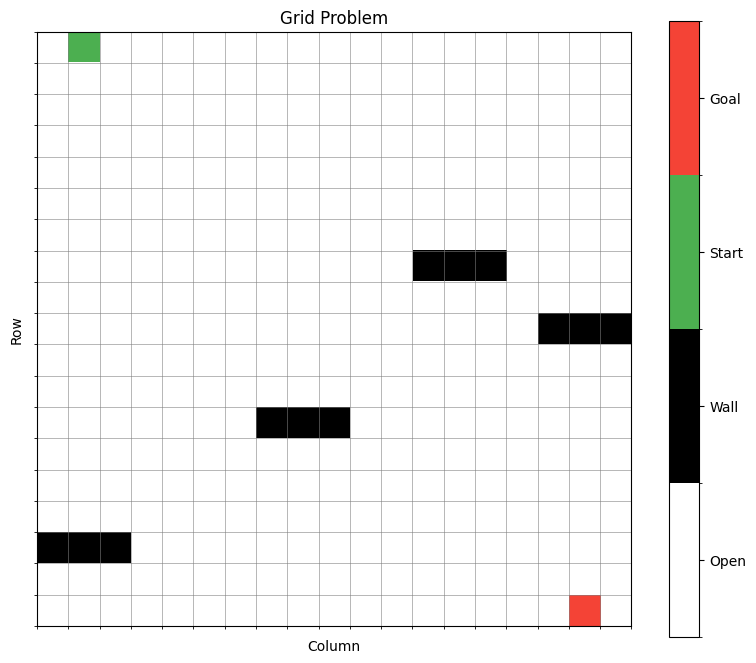

(<Figure size 800x800 with 2 Axes>,
 <Axes: title={'center': 'Grid Problem'}, xlabel='Column', ylabel='Row'>)

In [7]:
# Create experiment instance
experiment = GridExperiment(problem)

display_grid(
    experiment.problem.grid,
    start_node=experiment.problem.start_node,
    end_node=experiment.problem.end_node,
    title="Grid Problem"
)

## 4. Run Visual Experiment with Frontier Tracking

In [ ]:
# Define algorithms to test
algorithms = ['DFS', 'AStarSearch', 'BFS', 'UCS', 'GreedyBestFirst']

print(f"Running visual experiment with algorithms: {algorithms}")
print("This will track frontier expansion for animation...")

# Run visual experiment (with frontier recording)
trace = experiment.visualize(algorithms, trace_path='traces/demo_trace.pkl')

print("\n✓ Visual experiment completed")
print(f"  Trace saved to: demo_trace.pkl")
print(f"  Algorithms run: {list(trace['algorithms'].keys())}")

# Display results summary
for algo_name, result in trace['algorithms'].items():
    path_length = result.get('path_length', 'N/A')
    nodes_expanded = result.get('nodes_expanded', 'N/A')
    time_taken = result.get('execution_time_seconds', 'N/A')
    explored_len = len(result.get('explored_nodes_history', []))
    frontier_len = len(result.get('frontier_history', []))
    
    print(f"\n{algo_name}:")
    print(f"  Path length: {path_length}")
    print(f"  Nodes expanded: {nodes_expanded}")
    print(f"  Execution time: {time_taken}s")
    print(f"  Explored history: {explored_len} steps")
    print(f"  Frontier history: {frontier_len} steps")

Running visual experiment with algorithms: ['DFS', 'AStarSearch', 'BFS', 'UCS', 'GreedyBestFirst']
This will track frontier expansion for animation...
Running visual experiment on 19x19 grid...
Running DFS...
  ✓ DFS completed
Running AStarSearch...
  ✓ AStarSearch completed
Running BFS...
  ✓ BFS completed
Running UCS...
  ✓ UCS completed
Running GreedyBestFirst...
  ✓ GreedyBestFirst completed
Trace saved to: demo_trace.pkl

✓ Visual experiment completed
  Trace saved to: demo_trace.pkl
  Algorithms run: ['DFS', 'AStarSearch', 'BFS', 'UCS', 'GreedyBestFirst']

DFS:
  Path length: 237
  Nodes expanded: 340
  Execution time: 0.004654645919799805s
  Explored history: 340 steps
  Frontier history: 398 steps

AStarSearch:
  Path length: 35
  Nodes expanded: 309
  Execution time: 0.0019559860229492188s
  Explored history: 309 steps
  Frontier history: 309 steps

BFS:
  Path length: 35
  Nodes expanded: 344
  Execution time: 0.0012712478637695312s
  Explored history: 345 steps
  Frontier hi

## 5. Create Expansion Animation

MovieWriter ffmpeg unavailable; using Pillow instead.


Creating expansion animation for BFS...


ValueError: unknown file extension: .mp4

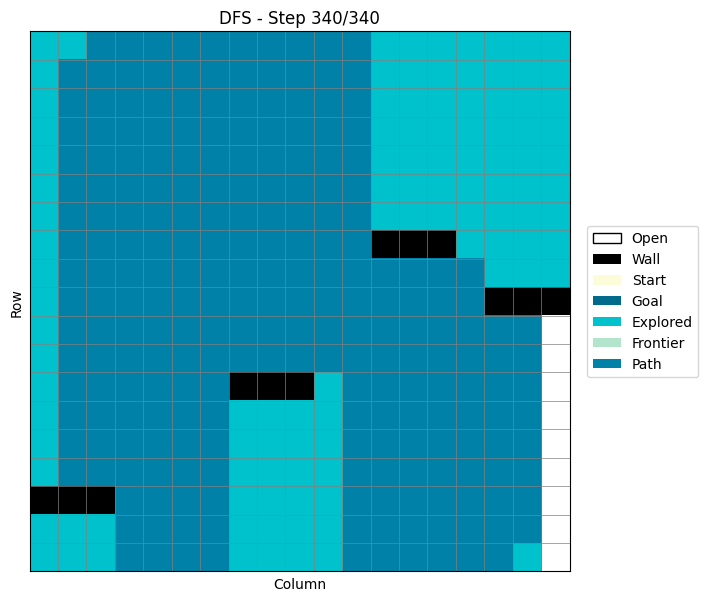

In [9]:
%matplotlib inline
# Create animation for BFS
print("Creating expansion animation for BFS...")
anim_bfs = create_grid_animation(trace, 'DFS', interval=20, save_path="outputs/videos.mp4")

# Display the animation
from IPython.display import HTML
HTML(anim_bfs.to_html5_video())

In [12]:
import matplotlib.animation as animation
animation.writers.list()

['pillow', 'ffmpeg', 'ffmpeg_file', 'html']

## 6. Compare Final Paths

In [ ]:
# Plot path comparison
fig = plot_path_comparison(trace, algorithms)
plt.show()


## 7. Run Benchmark Experiment

In [ ]:
# Run benchmark on the same grid
print("Running benchmark experiment...")
benchmark_df = experiment.benchmark(algorithms + ['GreedyBestFirst'], csv_path='outputs/demo_benchmark.csv')

print("\n✓ Benchmark completed")
print("Results saved to: demo_benchmark.csv")

# Display the results
print("\nBenchmark Results:")
print(benchmark_df.to_string(index=False))

## 8. Performance Analysis

In [ ]:
# Create performance comparison plots
fig = plot_performance_comparison('outputs/demo_benchmark.csv')
plt.show()

print("Performance comparison shows:")
print("- Path Length: How optimal is each solution?")
print("- Nodes Expanded: Computational complexity")
print("- Execution Time: Speed comparison")
print("\nNote: A* typically finds optimal paths but may expand more nodes than greedy approaches.")

## 9. Advanced: Larger Grid Benchmark

In [ ]:
# Create a larger random grid for benchmark comparison
print("Creating larger random grid for benchmark...")
large_experiment = GridExperiment.random(rows=100, cols=100, obstacle_prob=0.3, seed=42)

print(f"Large grid: {large_experiment.problem.n} × {large_experiment.problem.m}")
print(f"Obstacle probability: 30%")

# Run benchmark on large grid
large_benchmark = large_experiment.benchmark(
    ['BFS', 'AStarSearch', 'GreedyBestFirst'], 
    csv_path='outputs/large_benchmark.csv'
)

print("\nLarge grid benchmark results:")
print(large_benchmark[['algorithm', 'best_fitness', 'nodes_expanded', 'execution_time_seconds']].to_string(index=False))

## Summary

This notebook demonstrated the complete grid pathfinding experiment framework:

### Key Features Covered:

1. **Problem Loading**: Reading grids from test files or generating random grids
2. **Visual Experiments**: Frontier tracking and expansion animations
3. **Benchmark Experiments**: Performance metrics collection and analysis
4. **Visualization**: Path comparisons, performance plots, convergence curves
5. **Interactive Exploration**: Configurable experiments with widgets

### Algorithms Demonstrated:
- **Classic Search**: BFS, DFS, UCS, Greedy Best-First, A*
- **Metaheuristics**: GA_Grid, ACO_Grid

### Analysis Metrics:
- **Solution Quality**: Path length optimality
- **Computational Complexity**: Nodes expanded, execution time
- **Search Strategy**: Exploration vs exploitation patterns

### Usage Patterns:

```bash
# Visual mode (small grids)
python experiments/grid_experiment.py --mode visual --grid-file tests/SP/test_1.txt --algorithms BFS,A* --out trace.pkl

# Benchmark mode (large grids)
python experiments/grid_experiment.py --mode benchmark --rows 500 --cols 500 --algorithms BFS,A*,GA_Grid --out results.csv
```

### Next Steps:

1. Experiment with different grid sizes and obstacle densities
2. Compare algorithm performance across multiple test cases
3. Analyze the trade-offs between optimality and computational efficiency
4. Extend to multi-objective pathfinding (shortest path + minimal turns)

The framework is designed to be extensible - you can easily add new algorithms, problems, or visualization types!